# Analyzing Patterns based on Polycystic Ovary Syndrome (PCOS)/Polyendocrine Metabolic Ovarian Syndrome (PMOS) Gene Expression using R
**Dataset:** GSE34526 (NCBI Gene Expression Omnibus)  
**Platform:** Google Colab (R Runtime)  
**Objective:** Demonstrate R as a tool for Data Analysis and Visualization

In [114]:
system('git clone https://github.com/zhabcunanan/gene-expression-with-r.git')

## Section 0: Install and Load Packages

In [75]:
# Install packages
install.packages(c("ggplot2", "pheatmap", "corrplot", "glmnet", "randomForest", "pROC"),
                 repos = "https://cloud.r-project.org", quiet = TRUE)

# Install Bioconductor packages
if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager", repos = "https://cloud.r-project.org")

BiocManager::install(c("GEOquery", "limma", "preprocessCore", "impute", "sva"),
                     ask = FALSE, update = FALSE)

cat("All packages installed successfully.\n")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'GEOquery' 'limma' 'preprocessCore' 'impute'
  'sva'”


All packages installed successfully.


### Troubleshooting `glmnet` Installation

The `installation of package ‘glmnet’ had non-zero exit status` error often indicates that required system-level development libraries are missing. Let's install some common ones that R packages might need for compilation, such as `build-essential` (for basic compilation tools) and `libssl-dev` (often needed for secure communication libraries that some R packages depend on).

*This specific cell was assisted by Google Colab's Gemini*

In [76]:
# Install system dependencies required for R package compilation
system('apt-get update -qq')
system('apt-get install -y -qq build-essential libssl-dev')

print("System dependencies installed. Please re-run the R package installation cell (cell `73da61cc`) now.")

[1] "System dependencies installed. Please re-run the R package installation cell (cell `73da61cc`) now."


In [77]:
# Load all libraries
suppressMessages({
  library(GEOquery)
  library(limma)
  library(preprocessCore)
  library(impute)
  library(sva)
  library(ggplot2)
  library(pheatmap)
  library(corrplot)
  library(glmnet)
  library(randomForest)
  library(pROC)
})

cat("All libraries loaded successfully.\n")

All libraries loaded successfully.


---
## Section 1: Data Acquisition
Downloading **GSE34526** from NCBI GEO.  
This dataset contains granulosa cell gene expression profiles from PCOS patients and healthy controls.


In [78]:
cat("Downloading GSE34526 from NCBI GEO\n")

gse <- getGEO("GSE34526", GSEMatrix = TRUE, AnnotGPL = TRUE)

# Extract expression matrix and metadata
exprs_raw <- exprs(gse[[1]])    # Gene expression matrix (genes x samples)
pheno_data <- pData(gse[[1]])   # Sample metadata
feature_data <- fData(gse[[1]]) # Gene annotation

cat("Download complete.\n")
cat("\n Dataset Dimensions (Genes x Samples):\n")
print(dim(exprs_raw))

cat("\n Sample Metadata Columns:\n")
print(colnames(pheno_data))

Found 1 file(s)

GSE34526_series_matrix.txt.gz

Using locally cached version: /tmp/RtmpY6EMaa/GSE34526_series_matrix.txt.gz

Using locally cached version of GPL570 found here:
/tmp/RtmpY6EMaa/GPL570.annot.gz 



Download complete.

 Dataset Dimensions (Genes x Samples):
[1] 54675    10

 Sample Metadata Columns:
 [1] "title"                   "geo_accession"          
 [3] "status"                  "submission_date"        
 [5] "last_update_date"        "type"                   
 [7] "channel_count"           "source_name_ch1"        
 [9] "organism_ch1"            "characteristics_ch1"    
[11] "characteristics_ch1.1"   "treatment_protocol_ch1" 
[13] "growth_protocol_ch1"     "molecule_ch1"           
[15] "extract_protocol_ch1"    "label_ch1"              
[17] "label_protocol_ch1"      "taxid_ch1"              
[19] "hyb_protocol"            "scan_protocol"          
[21] "description"             "data_processing"        
[23] "platform_id"             "contact_name"           
[25] "contact_email"           "contact_laboratory"     
[27] "contact_department"      "contact_institute"      
[29] "contact_address"         "contact_city"           
[31] "contact_zip/postal_code" "contact_cou

In [79]:
# Preview sample conditions
cat("Sample Conditions:\n")
print(table(pheno_data$characteristics_ch1))

cat("\nFirst 5 rows and 3 columns of expression matrix:\n")
print(exprs_raw[1:5, 1:3])

Sample Conditions:

cell type: granulosa cells 
                        10 

First 5 rows and 3 columns of expression matrix:
           GSM850527  GSM850528  GSM850529
1007_s_at 1827.70017 2735.92116 3528.26807
1053_at     98.71526  361.32015  308.84969
117_at      53.14153  552.69475  505.49821
121_at     510.72981  476.99926  535.26582
1255_g_at   95.85222   75.36596   92.87307


---
## Section 2: Data Cleaning
Steps: Inspection → Missing Value Imputation → Normalization → Batch Effect Check


In [80]:
# ── 2.1 Initial Inspection ──────────────────────────────────────────────
cat("Checking missing values...\n")
cat("Total NAs in raw data:", sum(is.na(exprs_raw)), "\n")
cat("\nSummary of first 5 genes:\n")
print(summary(exprs_raw[1:5, ]))

Checking missing values...
Total NAs in raw data: 0 

Summary of first 5 genes:
   GSM850527         GSM850528         GSM850529         GSM850530      
 Min.   :  53.14   Min.   :  75.37   Min.   :  92.87   Min.   :  44.94  
 1st Qu.:  95.85   1st Qu.: 361.32   1st Qu.: 308.85   1st Qu.: 266.35  
 Median :  98.72   Median : 477.00   Median : 505.50   Median : 631.60  
 Mean   : 517.23   Mean   : 840.46   Mean   : 994.15   Mean   : 866.80  
 3rd Qu.: 510.73   3rd Qu.: 552.69   3rd Qu.: 535.27   3rd Qu.: 693.41  
 Max.   :1827.70   Max.   :2735.92   Max.   :3528.27   Max.   :2697.70  
   GSM850531         GSM850532         GSM850533          GSM850534     
 Min.   :  36.25   Min.   :  47.13   Min.   :   9.522   Min.   :  71.4  
 1st Qu.: 446.13   1st Qu.: 319.04   1st Qu.: 306.355   1st Qu.: 393.7  
 Median : 459.35   Median : 663.87   Median : 469.711   Median : 444.5  
 Mean   : 747.63   Mean   :1074.83   Mean   : 937.918   Mean   : 685.9  
 3rd Qu.:1321.53   3rd Qu.:1241.07   3rd Qu.

In [81]:
# ── 2.2 Missing Value Imputation ────────────────────────────────────────

# Remove genes missing in more than 20% of samples
missing_threshold <- 0.20
keep_genes <- rowSums(is.na(exprs_raw)) < (ncol(exprs_raw) * missing_threshold)
exprs_clean <- exprs_raw[keep_genes, ]
cat("Genes remaining after NA threshold filter:", nrow(exprs_clean), "\n")

# Apply kNN imputation if NAs remain
if (sum(is.na(exprs_clean)) > 0) {
  exprs_imputed <- impute.knn(exprs_clean)$data
  cat("kNN imputation applied.\n")
} else {
  exprs_imputed <- exprs_clean
  cat("No imputation needed — dataset has no missing values.\n")
}

Genes remaining after NA threshold filter: 54675 
No imputation needed — dataset has no missing values.


ERROR: Error in normalize.quantiles(as.matrix(exprs_imputed)): ERROR; return code from pthread_create() is 22



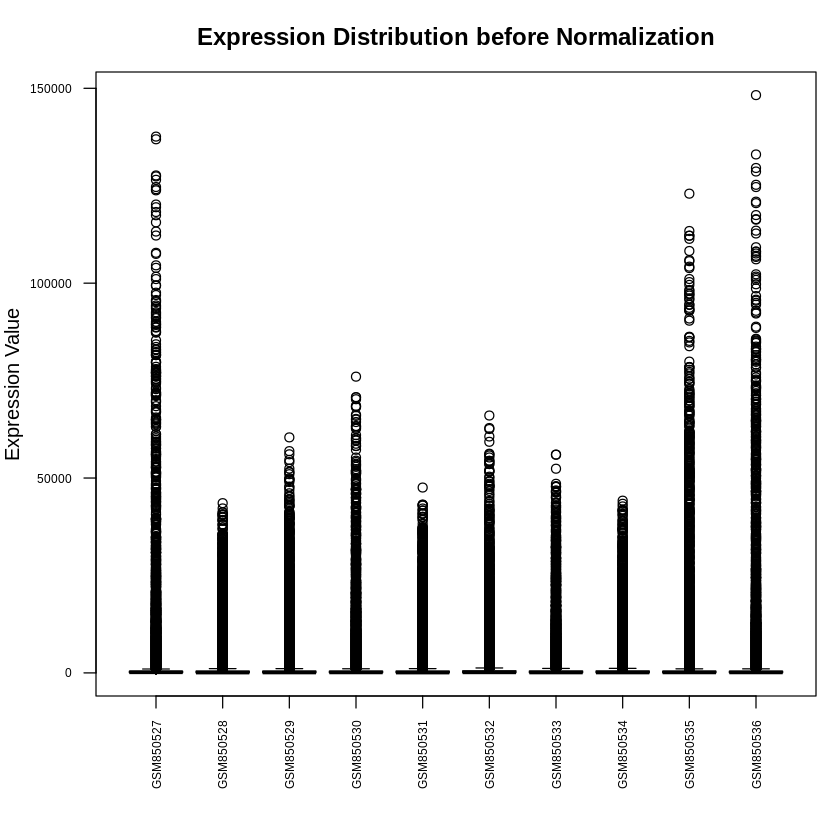

In [82]:
# ── 2.3 Normalization ────────────────────────────────────────────────────

# Before boxplot
par(mar = c(6, 4, 3, 1))
boxplot(exprs_imputed[, 1:min(20, ncol(exprs_imputed))],
        main = "Expression Distribution before Normalization",
        las = 2, col = "lightcoral",
        ylab = "Expression Value", xlab = "", cex.axis = 0.6)

# Normalize quantiles
# Set environment variables to prevent threading issues in preprocessCore and underlying BLAS/LAPACK libraries
Sys.setenv(OMP_NUM_THREADS = 1)
Sys.setenv(R_NCPUS = 1)
Sys.setenv(BLAS_NUM_THREADS = 1)
Sys.setenv(OPENBLAS_NUM_THREADS = 1)
Sys.setenv(MKL_NUM_THREADS = 1)
Sys.setenv(GOTOBLAS_NUM_THREADS = 1)
Sys.setenv(VECLIB_MAXIMUM_THREADS = 1)
exprs_norm <- normalize.quantiles(as.matrix(exprs_imputed))
rownames(exprs_norm) <- rownames(exprs_imputed)
colnames(exprs_norm) <- colnames(exprs_imputed)

# After boxplot
boxplot(exprs_norm[, 1:min(20, ncol(exprs_norm))],
        main = "Expression Distribution after Normalization",
        las = 2, col = "lightblue",
        ylab = "Expression Value", xlab = "", cex.axis = 0.6)

cat("Quantile normalization applied.\n")

### Alternative Normalization Method: `normalizeBetweenArrays` (Cyclic Loess)

As `preprocessCore::normalize.quantiles` encountered persistent threading errors, we can use `limma::normalizeBetweenArrays` with a different method. `Cyclic Loess` is a robust normalization method often used for microarray data.

This method performs a LOESS (Locally Estimated Scatterplot Smoothing) regression between all pairs of arrays to normalize the data. It's an iterative process that can handle non-linear relationships between arrays.

*This specific cell was assisted by Google Colab's Gemini*

Cyclic Loess normalization applied successfully.


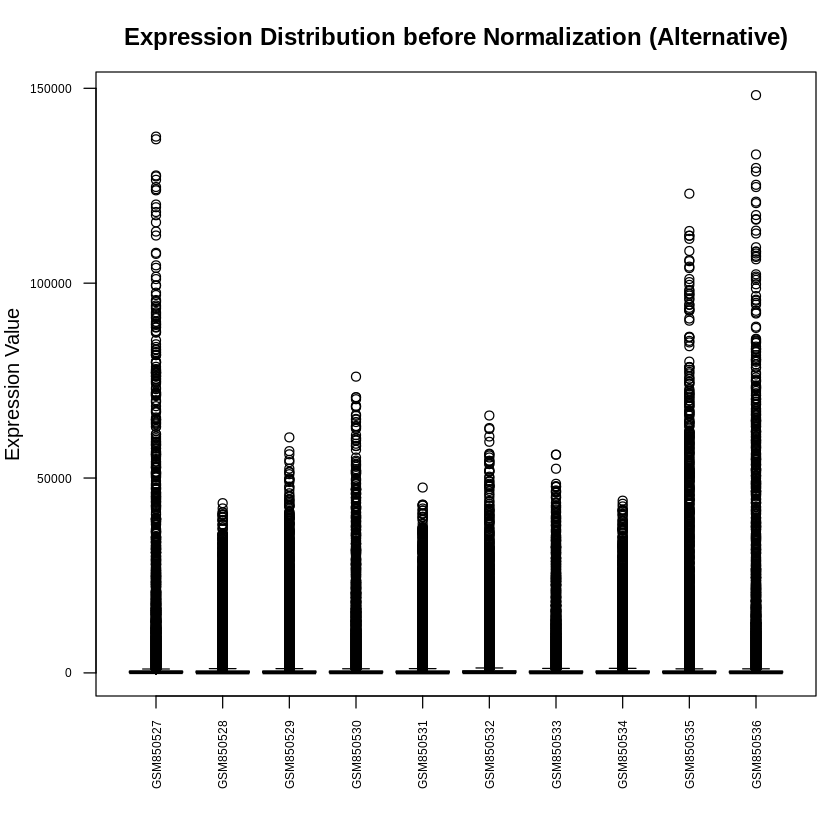

If this method is successful, you can continue the analysis using `exprs_norm_alternative` instead of `exprs_norm` for subsequent steps.

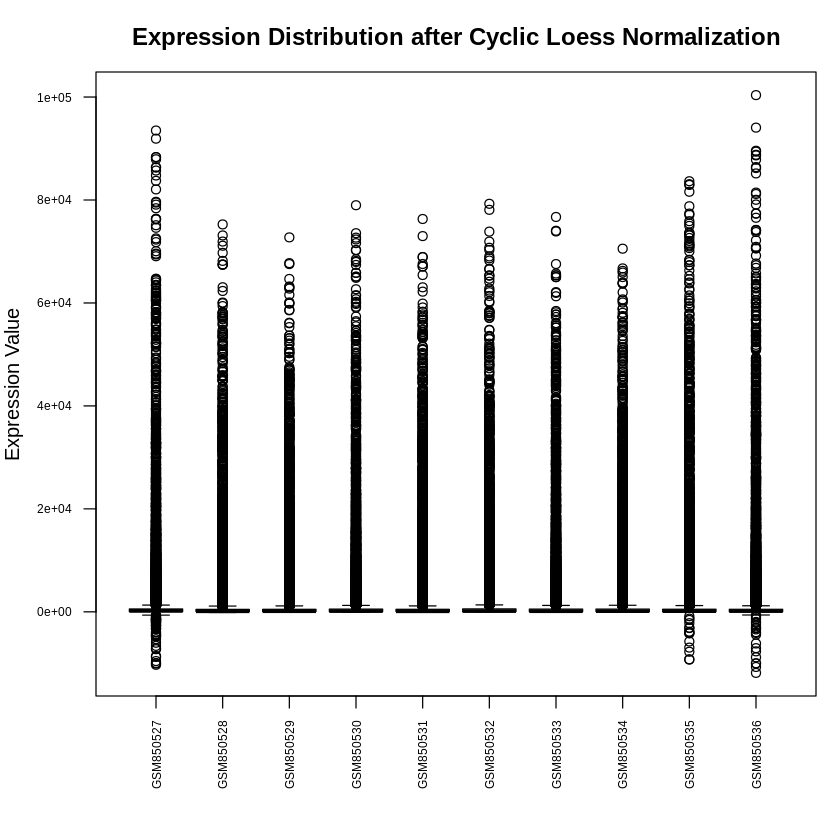

In [83]:
# ── 2.3 Alternative Normalization (Cyclic Loess) ─────────────────────────

# Before boxplot (using exprs_imputed which is the pre-normalization data)
par(mar = c(6, 4, 3, 1))
boxplot(exprs_imputed[, 1:min(20, ncol(exprs_imputed))],
        main = "Expression Distribution before Normalization (Alternative)",
        las = 2, col = "lightcoral",
        ylab = "Expression Value", xlab = "", cex.axis = 0.6)

# Apply Cyclic Loess normalization
# Note: limma is already loaded in cell 57b1982c
exprs_norm_alternative <- normalizeBetweenArrays(as.matrix(exprs_imputed), method = "cyclicloess")
rownames(exprs_norm_alternative) <- rownames(exprs_imputed)
colnames(exprs_norm_alternative) <- colnames(exprs_imputed)

cat("Cyclic Loess normalization applied successfully.\n")

# After boxplot
boxplot(exprs_norm_alternative[, 1:min(20, ncol(exprs_norm_alternative))],
        main = "Expression Distribution after Cyclic Loess Normalization",
        las = 2, col = "lightblue",
        ylab = "Expression Value", xlab = "", cex.axis = 0.6)

cat("If this method is successful, you can continue the analysis using `exprs_norm_alternative` instead of `exprs_norm` for subsequent steps.")

In [84]:
# ── 2.4 Batch Effect Check ───────────────────────────────────────────────
# NOTE: Uncomment and configure batch vector if merging multiple GEO datasets

# batch <- c(1,1,1,...,2,2,2,...)   # Define your batch labels here
# exprs_norm <- ComBat(dat = exprs_norm, batch = batch)
# cat("ComBat batch correction applied.\n")

cat("Batch correction skipped (single dataset — GSE34526).\n")
cat("Uncomment the ComBat lines above if merging multiple datasets.\n")

Batch correction skipped (single dataset — GSE34526).
Uncomment the ComBat lines above if merging multiple datasets.


---
## Section 3: Data Filtering
Low-Expression → Low-Variance → Unmapped Probes


In [85]:
# ── 3.1 Filter Low-Expression Genes ─────────────────────────────────────
low_expr_filter <- rowMeans(exprs_norm_alternative) > log2(10)
exprs_filtered <- exprs_norm_alternative[low_expr_filter, ]
cat("Genes after low-expression filter:", nrow(exprs_filtered), "\n")

Genes after low-expression filter: 54675 


In [86]:
# ── 3.2 Filter Low-Variance Genes ───────────────────────────────────────
gene_vars <- apply(exprs_filtered, 1, var)
variance_threshold <- quantile(gene_vars, 0.50)   # Keep top 50% most variable
exprs_filtered <- exprs_filtered[gene_vars >= variance_threshold, ]
cat("Genes after low-variance filter:", nrow(exprs_filtered), "\n")

Genes after low-variance filter: 27338 


In [87]:
# ── 3.3 Filter Unmapped Probes ──────────────────────────────────────────
# Check available column names in feature_data for gene symbols.
# It's possible 'Gene Symbol' is not the correct column name for this dataset's GPL annotation.
# Common alternatives include 'GENE_SYMBOL', 'Symbol', 'Gene name', etc.
# If the code still errors, inspect `colnames(feature_data)` to find the correct column name.

gene_symbol_col_name <- NULL
possible_names <- c("Gene Symbol", "GENE_SYMBOL", "Symbol", "Gene name", "Gene symbol")

for (name in possible_names) {
  if (name %in% colnames(feature_data)) {
    gene_symbol_col_name <- name
    break
  }
}

if (is.null(gene_symbol_col_name)) {
  stop("Could not find a 'Gene Symbol' or similar column in feature_data. Please inspect colnames(feature_data) to identify the correct column name for gene symbols.")
}

gene_symbols <- feature_data[[gene_symbol_col_name]]
names(gene_symbols) <- rownames(feature_data)
mapped <- gene_symbols[rownames(exprs_filtered)]
exprs_filtered <- exprs_filtered[!is.na(mapped) & mapped != "", ]
cat("Genes after unmapped probe filter:", nrow(exprs_filtered), "\n")
cat("\nFinal gene count for analysis:", nrow(exprs_filtered), "\n")

Genes after unmapped probe filter: 24110 

Final gene count for analysis: 24110 


In [88]:
print(colnames(feature_data))

 [1] "ID"                    "Gene title"            "Gene symbol"          
 [4] "Gene ID"               "UniGene title"         "UniGene symbol"       
 [7] "UniGene ID"            "Nucleotide Title"      "GI"                   
[10] "GenBank Accession"     "Platform_CLONEID"      "Platform_ORF"         
[13] "Platform_SPOTID"       "Chromosome location"   "Chromosome annotation"
[16] "GO:Function"           "GO:Process"            "GO:Component"         
[19] "GO:Function ID"        "GO:Process ID"         "GO:Component ID"      


---
## Section 4: Exploratory Data Analysis (EDA)
Visualize data quality and confirm preprocessing before modeling.


In [89]:
# ── 4.1 Define Sample Groups ─────────────────────────────────────────────

# Adjust grepl pattern if metadata label differs in your dataset
# Using 'disease:ch1' based on available pheno_data columns, assuming it contains PCOS/Control info.
condition <- ifelse(pheno_data[['disease:ch1']] == "Polycystic ovary Syndrome", "PCOS", "Control")
condition <- factor(condition, levels = c("Control", "PCOS"))

cat("Sample group counts:\n")
print(table(condition))

Sample group counts:
condition
Control    PCOS 
      3       7 


In [90]:
cat("Unique values in 'disease:ch1':\n")
print(unique(pheno_data[['disease:ch1']]))

Unique values in 'disease:ch1':
[1] "normal"                    "Polycystic ovary Syndrome"


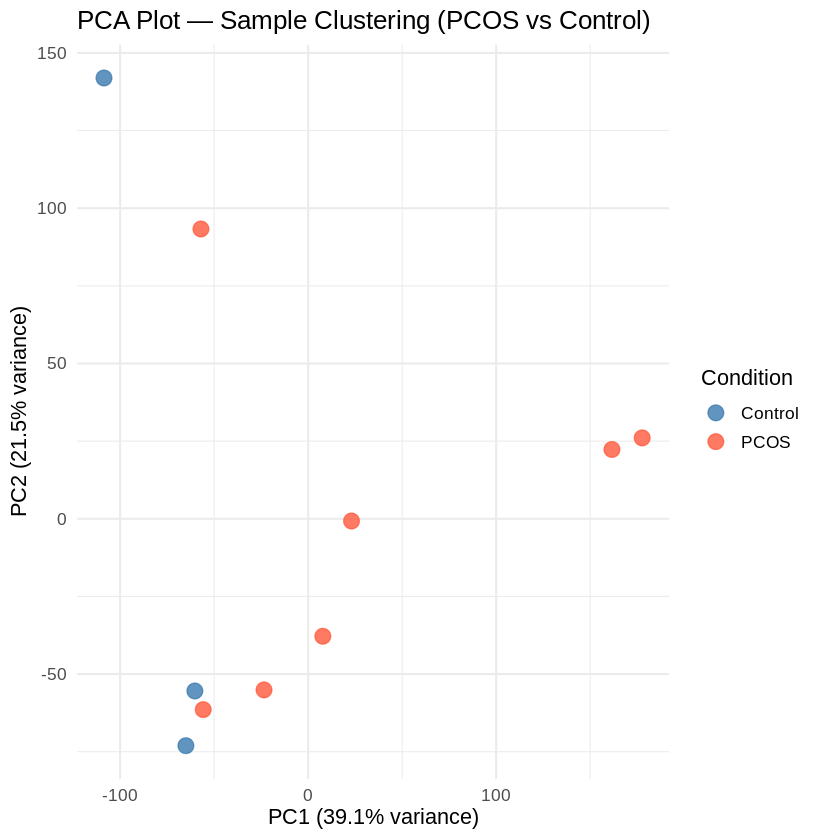

In [91]:
# ── 4.2 PCA Plot — Sample Clustering ────────────────────────────────────
pca    <- prcomp(t(exprs_filtered), scale. = TRUE)
pca_df <- data.frame(
  PC1 = pca$x[, 1],
  PC2 = pca$x[, 2],
  Condition = condition
)

var_explained <- summary(pca)$importance[2, ] * 100

ggplot(pca_df, aes(x = PC1, y = PC2, color = Condition)) +
  geom_point(size = 4, alpha = 0.85) +
  scale_color_manual(values = c("Control" = "steelblue", "PCOS" = "tomato")) +
  labs(
    title = "PCA Plot — Sample Clustering (PCOS vs Control)",
    x = paste0("PC1 (", round(var_explained[1], 1), "% variance)"),
    y = paste0("PC2 (", round(var_explained[2], 1), "% variance)")
  ) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "right")

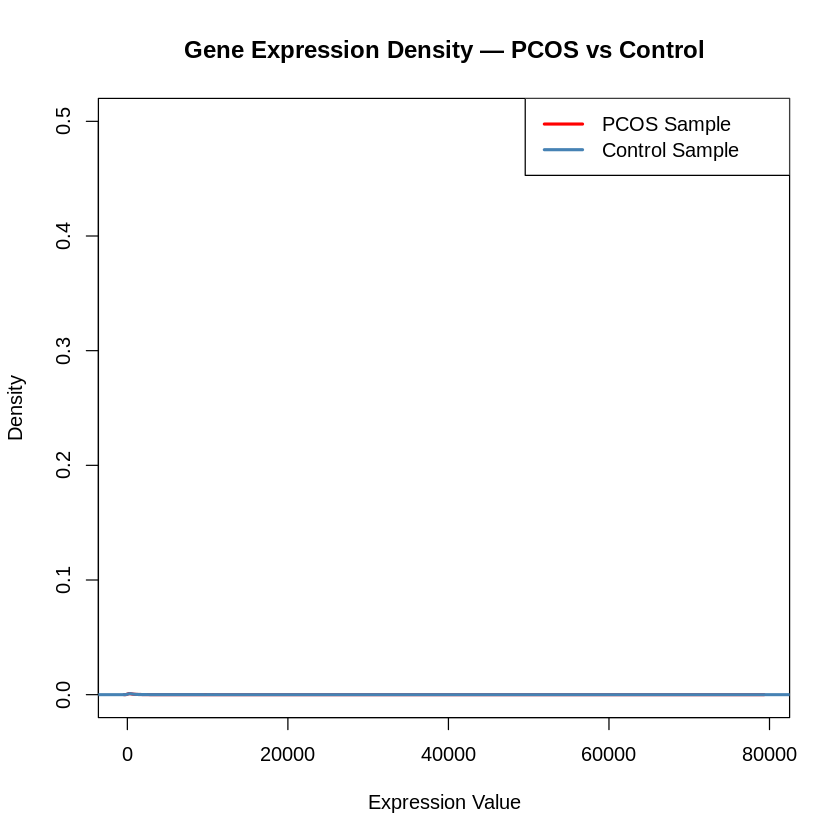

In [92]:
# ── 4.3 Density Plot ─────────────────────────────────────────────────────
# Initialize plotting parameters
main_title <- "Gene Expression Density"
xlab_label <- "Expression Value"
ylab_label <- "Density"
ylim_range <- c(0, 0.5)

# Get indices for PCOS and Control
pcos_indices    <- which(condition == "PCOS")
control_indices <- which(condition == "Control")

# Prepare data for plotting, ensuring no NAs and valid length
pcos_data <- numeric(0)
control_data <- numeric(0)

pcos_exists <- FALSE
if (length(pcos_indices) > 0) {
  pcos_idx <- pcos_indices[1]
  # Ensure the subsetted data is not all NAs and has elements
  temp_pcos_data <- na.omit(exprs_filtered[, pcos_idx])
  if (length(temp_pcos_data) > 0) {
    pcos_data <- temp_pcos_data
    pcos_exists <- TRUE
  } else {
    warning("No valid non-NA data for 'PCOS' samples after subsetting.")
  }
} else {
  warning("No 'PCOS' samples found in 'condition' variable. Cannot plot PCOS density.")
}

control_exists <- FALSE
if (length(control_indices) > 0) {
  control_idx <- control_indices[1]
  # Ensure the subsetted data is not all NAs and has elements
  temp_control_data <- na.omit(exprs_filtered[, control_idx])
  if (length(temp_control_data) > 0) {
    control_data <- temp_control_data
    control_exists <- TRUE
  } else {
    warning("No valid non-NA data for 'Control' samples after subsetting.")
  }
} else {
  warning("No 'Control' samples found in 'condition' variable. Cannot plot Control density.")
}


# Plotting logic
if (pcos_exists && control_exists) {
  # Both exist, plot both
  main_title <- "Gene Expression Density — PCOS vs Control"
  plot(density(pcos_data),
       main = main_title,
       xlab = xlab_label, col = "red", lwd = 2.5, ylim = ylim_range)
  lines(density(control_data), col = "steelblue", lwd = 2.5)
  legend("topright",
         legend = c("PCOS Sample", "Control Sample"),
         col = c("red", "steelblue"), lwd = 2.5)
} else if (control_exists) {
  # Only Control exists
  main_title <- "Gene Expression Density — Control Sample"
  plot(density(control_data),
       main = main_title,
       xlab = xlab_label, col = "steelblue", lwd = 2.5, ylim = ylim_range)
  legend("topright",
         legend = c("Control Sample"),
         col = c("steelblue"), lwd = 2.5)
} else if (pcos_exists) {
  # Only PCOS exists
  main_title <- "Gene Expression Density — PCOS Sample"
  plot(density(pcos_data),
       main = main_title,
       xlab = xlab_label, col = "red", lwd = 2.5, ylim = ylim_range)
  legend("topright",
         legend = c("PCOS Sample"),
         col = c("red"), lwd = 2.5)
} else {
  # Neither exists or no valid data points after NA removal
  message("Neither 'PCOS' nor 'Control' samples found, or no valid data points after NA removal. Cannot generate density plot.")
}

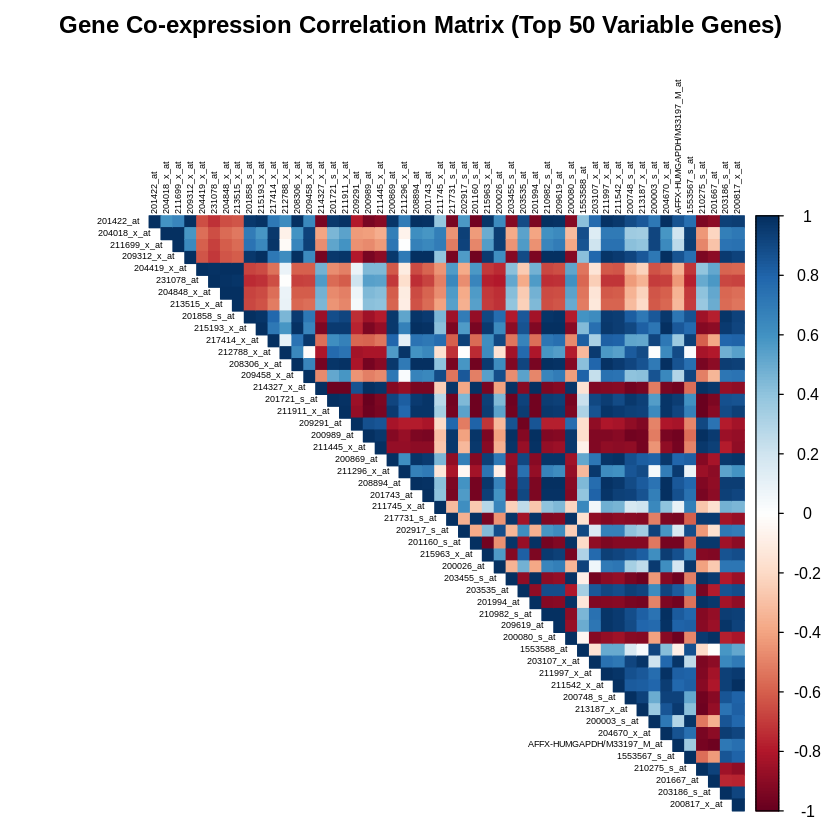

In [93]:
# ── 4.4 Correlation Matrix (Top 50 Variable Genes) ──────────────────────
top50_var  <- names(sort(apply(exprs_filtered, 1, var), decreasing = TRUE)[1:50])
cor_matrix <- cor(t(exprs_filtered[top50_var, ]), method = "pearson")

corrplot(cor_matrix,
         method = "color",
         type = "upper",
         tl.cex = 0.45,
         tl.col = "black",
         title = "Gene Co-expression Correlation Matrix (Top 50 Variable Genes)",
         mar = c(0, 0, 2, 0))

---
## Section 5: Statistical Analysis and Modeling
Models: **Limma DEG → Linear Regression → Lasso/Elastic Net → Random Forest → ROC Curve**


In [94]:
# ── 5.1 Differential Expression Analysis (limma) ────────────────────────

# Build design matrix
design <- model.matrix(~ condition)
colnames(design) <- c("Intercept", "PCOS_vs_Control")

# Fit linear model per gene + empirical Bayes moderation
fit  <- lmFit(exprs_filtered, design)
fit2 <- eBayes(fit)

# Extract all results with BH FDR correction
deg_results <- topTable(fit2,
                         coef = "PCOS_vs_Control",
                         number = Inf,
                         adjust.method = "BH",
                         sort.by = "P")

cat("Top 10 Differentially Expressed Genes:\n")
print(head(deg_results[, c("logFC", "AveExpr", "t", "P.Value", "adj.P.Val")], 10))

Top 10 Differentially Expressed Genes:
               logFC   AveExpr          t      P.Value  adj.P.Val
206336_at  -957.3155  541.4171 -10.227269 3.067031e-06 0.03464027
203799_at  2450.8668 4148.4447   9.617421 5.102754e-06 0.03464027
237302_at -1082.8596  643.2650  -9.374651 6.296791e-06 0.03464027
225812_at  -620.4522  620.3516  -9.311707 6.654520e-06 0.03464027
206825_at -3188.2248 1931.7086  -9.092852 8.083805e-06 0.03464027
229963_at -1307.4093 1254.0690  -9.021480 8.620556e-06 0.03464027
242488_at -1653.9426 1578.7796  -8.393460 1.546274e-05 0.04947062
201307_at -3930.1599 3257.8649  -8.268789 1.743665e-05 0.04947062
203373_at -1399.5203 1357.5564  -8.162293 1.934324e-05 0.04947062
213894_at  -668.1180  579.3698  -8.062905 2.133076e-05 0.04947062


In [95]:
# Filter significant DEGs
sig_degs <- deg_results[deg_results$adj.P.Val < 0.05 &
                           abs(deg_results$logFC) >= 0.585, ]

cat("\nDEG Summary:\n")
cat("Total significant DEGs    :", nrow(sig_degs), "\n")
cat("Upregulated in PCOS       :", sum(sig_degs$logFC > 0), "\n")
cat("Downregulated in PCOS     :", sum(sig_degs$logFC < 0), "\n")


DEG Summary:
Total significant DEGs    : 11 
Upregulated in PCOS       : 1 
Downregulated in PCOS     : 10 


Genes in volcano plot:

    Upregulated   Downregulated Not Significant 
              1              10           24099 


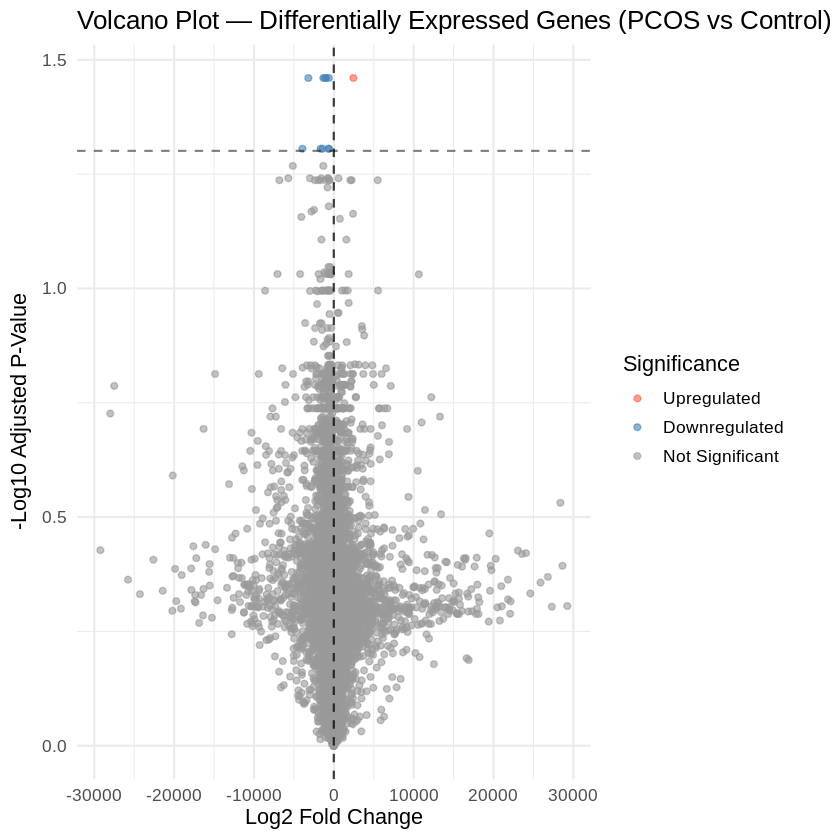

In [96]:
# ── 5.2 Volcano Plot ─────────────────────────────────────────────────────

# Remove rows with NA in key columns before plotting
deg_results_clean <- deg_results[
  !is.na(deg_results$adj.P.Val) & !is.na(deg_results$logFC),
]

# Assign significance groups
deg_results_clean$Significance <- "Not Significant"
deg_results_clean$Significance[deg_results_clean$adj.P.Val < 0.05 &
                                 deg_results_clean$logFC >=  0.585] <- "Upregulated"
deg_results_clean$Significance[deg_results_clean$adj.P.Val < 0.05 &
                                 deg_results_clean$logFC <= -0.585] <- "Downregulated"

# Convert to factor to ensure all levels render in legend
deg_results_clean$Significance <- factor(
  deg_results_clean$Significance,
  levels = c("Upregulated", "Downregulated", "Not Significant")
)

cat("Genes in volcano plot:\n")
print(table(deg_results_clean$Significance))

# Plot
ggplot(deg_results_clean, aes(x = logFC, y = -log10(adj.P.Val), color = Significance)) +
  geom_point(alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c(
    "Not Significant" = "grey60",
    "Upregulated"     = "tomato",
    "Downregulated"   = "steelblue"
  )) +
  geom_vline(xintercept = c(-0.585, 0.585), linetype = "dashed", alpha = 0.5) +
  geom_hline(yintercept = -log10(0.05),     linetype = "dashed", alpha = 0.5) +
  labs(
    title = "Volcano Plot — Differentially Expressed Genes (PCOS vs Control)",
    x     = "Log2 Fold Change",
    y     = "-Log10 Adjusted P-Value"
  ) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "right")

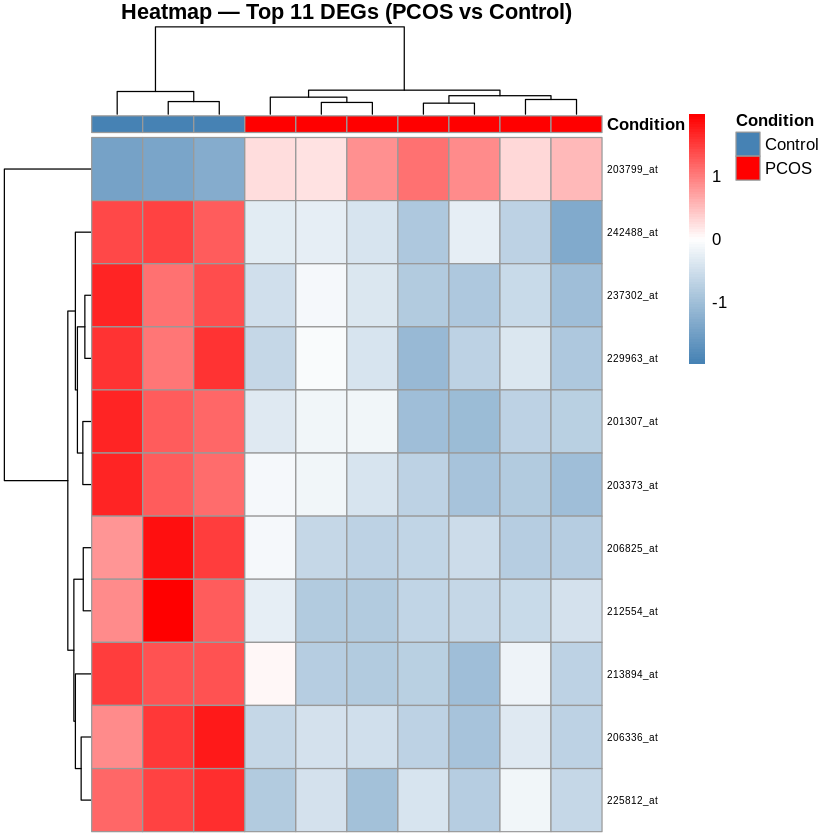

In [97]:
# ── 5.3 Heatmap of Top DEGs ──────────────────────────────────────────────

# Check if there are any significant DEGs before plotting
if (nrow(sig_degs) == 0) {
  message("No significant DEGs found. Cannot generate heatmap.")
} else {
  top_n        <- min(50, nrow(sig_degs))
  top_deg_names <- rownames(sig_degs)[1:top_n]
  heatmap_data  <- exprs_filtered[top_deg_names, ]

  annotation_col <- data.frame(Condition = condition)
  rownames(annotation_col) <- colnames(heatmap_data)

  ann_colors <- list(Condition = c(Control = "steelblue", PCOS = "red"))

  pheatmap(heatmap_data,
           annotation_col = annotation_col,
           annotation_colors = ann_colors,
           scale = "row",
           show_rownames = TRUE,
           show_colnames = FALSE,
           fontsize_row = 6,
           color = colorRampPalette(c("steelblue", "white", "red"))(100),
           main = paste("Heatmap — Top", top_n, "DEGs (PCOS vs Control)"))
}

Linear Regression, Top DEG: 206336_at 


Call:
lm(formula = gene_expression ~ condition_numeric)

Residuals:
    Min      1Q  Median      3Q     Max 
-234.58  -44.57   21.09   61.84  172.45 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)        1211.54      75.97   15.95 2.39e-07 ***
condition_numeric  -957.32      90.80  -10.54 5.71e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 131.6 on 8 degrees of freedom
Multiple R-squared:  0.9329,	Adjusted R-squared:  0.9245 
F-statistic: 111.2 on 1 and 8 DF,  p-value: 5.712e-06



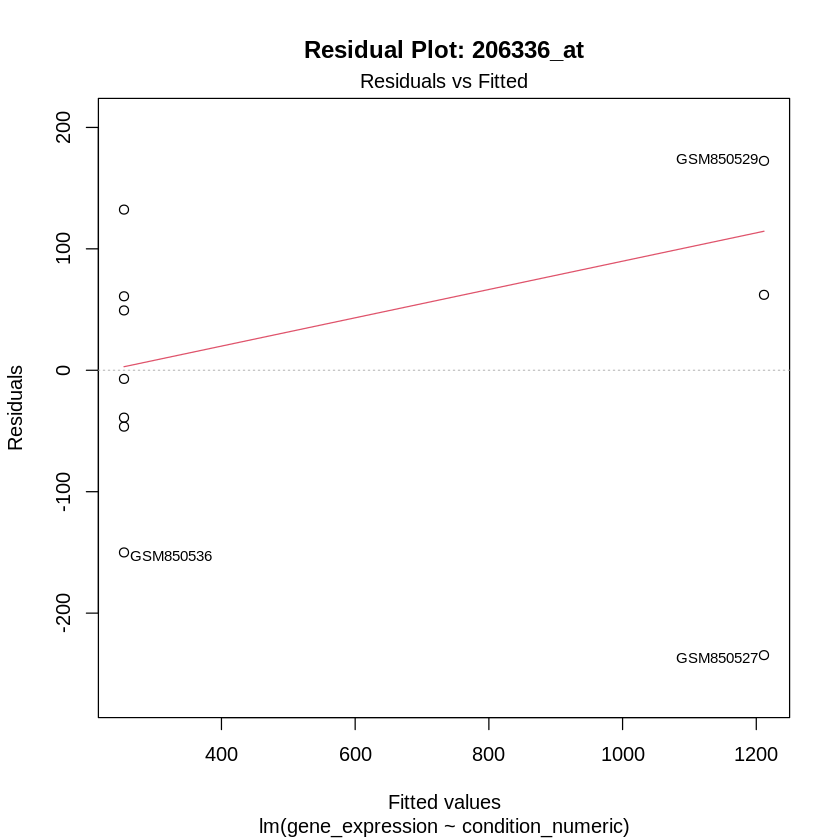

In [98]:
# ── 5.4 Linear Regression (Baseline Model) ───────────────────────────────
condition_numeric <- as.numeric(condition) - 1   # Control = 0, PCOS = 1
top_gene <- rownames(sig_degs)[1]
gene_expression <- exprs_filtered[top_gene, ]

lm_model <- lm(gene_expression ~ condition_numeric)

cat("Linear Regression, Top DEG:", top_gene, "\n\n")
print(summary(lm_model))

# Residual plot
plot(lm_model, which = 1,
     main = paste("Residual Plot:", top_gene))

In [99]:
# ── 5.5 Lasso / Elastic Net Regression ───────────────────────────────────
X <- t(exprs_filtered)           # Samples x Genes
y <- as.numeric(condition) - 1   # 0 = Control, 1 = PCOS

set.seed(42)

# Cross-validated Lasso
cv_lasso <- cv.glmnet(X, y, alpha = 1, family = "binomial", nfolds = 5)
cat("Optimal Lambda (Lasso):", round(cv_lasso$lambda.min, 5), "\n")

# Cross-validated Elastic Net
cv_enet  <- cv.glmnet(X, y, alpha = 0.5, family = "binomial", nfolds = 5)
cat("Optimal Lambda (Elastic Net):", round(cv_enet$lambda.min, 5), "\n")

# Plot Lasso CV curve
plot(cv_lasso, main = "Lasso — Cross-Validation Lambda Selection")

Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”


ERROR: Error in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, : one multinomial or binomial class has 1 or 0 observations; not allowed


### Explaining the `glmnet` Error and Alternative Approaches

The `glmnet` model failed with the error `one multinomial or binomial class has 1 or 0 observations; not allowed` because `glmnet`'s binomial family (used for binary classification like 'Control' vs 'PCOS') requires a minimum number of observations in each class (typically 8 or more) to perform stable cross-validation and parameter estimation. With only 3 'Control' and 7 'PCOS' samples, the model cannot be reliably fitted.

______
*The information from this point up to the end of the current cell was suggested by Google Colab's Gemini (except for the information above).*
______

For datasets with very small sample sizes, traditional asymptotic statistical methods and some machine learning models can struggle due to issues like perfect separation (where a feature perfectly predicts the outcome) or an insufficient number of data points to estimate parameters accurately. This can lead to inflated standard errors, unreliable p-values, or model convergence issues.

**Strategies for Small Sample Sizes:**

1.  **Non-parametric Models (e.g., Random Forest):** As demonstrated in this notebook, ensemble methods like Random Forest (`randomForest` package) are often more robust to smaller datasets. They can capture complex relationships without strong distributional assumptions and are less prone to issues like perfect separation, making them a suitable alternative when sample size is limited.
2.  **Exact Statistical Methods:** For very small samples, consider exact statistical tests (like Fisher's Exact Test for categorical data) or exact logistic regression (available in packages like `logistf` in R). These methods compute exact probabilities and confidence intervals, which are more reliable than asymptotic approximations when sample sizes are small.
3.  **Cross-Validation with Caution:** While cross-validation is crucial for model evaluation, with extremely small `N`, standard k-fold cross-validation can be unstable. Leave-One-Out Cross-Validation (LOOCV) might be considered, though it can be computationally intensive and still may not fully address the underlying lack of information.
4.  **Focus on Feature Importance from Robust Models:** Rather than complex predictive models, you might prioritize identifying the most important features (e.g., from `limma`'s differential expression analysis or Random Forest's variable importance) and build simpler, interpretable models.
5.  **Acquire More Data:** Ultimately, the most robust solution for small sample size problems is to increase the sample size if feasible. If not, acknowledge the limitations imposed by the small N in your conclusions.

Random Forest Summary:

Call:
 randomForest(x = X, y = as.factor(condition), ntree = 500, importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 155

        OOB estimate of  error rate: 10%
Confusion matrix:
        Control PCOS class.error
Control       2    1   0.3333333
PCOS          0    7   0.0000000


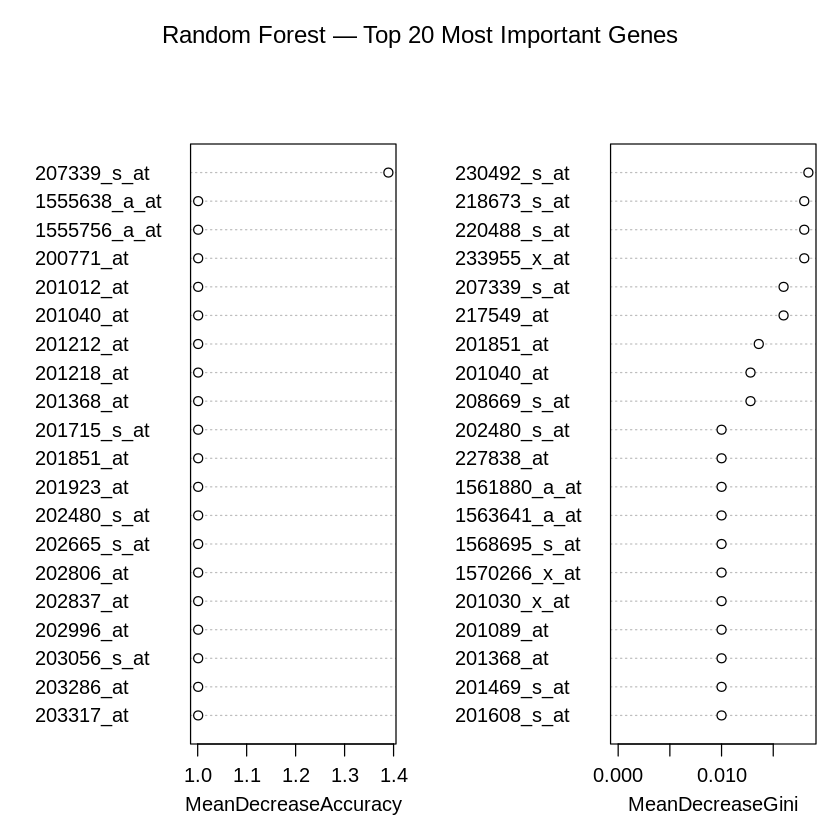

In [101]:
# ── 5.6 Random Forest (Optional) ─────────────────────────────────────────
set.seed(42)
rf_model <- randomForest(x = X,
                          y = as.factor(condition),
                          ntree = 500,
                          importance = TRUE)

cat("Random Forest Summary:\n")
print(rf_model)

# Variable importance plot
varImpPlot(rf_model, n.var = 20,
           main = "Random Forest — Top 20 Most Important Genes")

### Evaluating the Random Forest Model

Since the `glmnet` model failed due to small sample sizes, we will proceed with evaluating the `randomForest` model, which successfully ran and is generally more robust for smaller datasets. We will calculate the AUC and plot the ROC curve for the Random Forest model to assess its predictive performance.

*This specific cell was assisted by Google Colab's Gemini*

Setting levels: control = 0, case = 1

Setting direction: controls < cases




Random Forest Model AUC: 0.905 


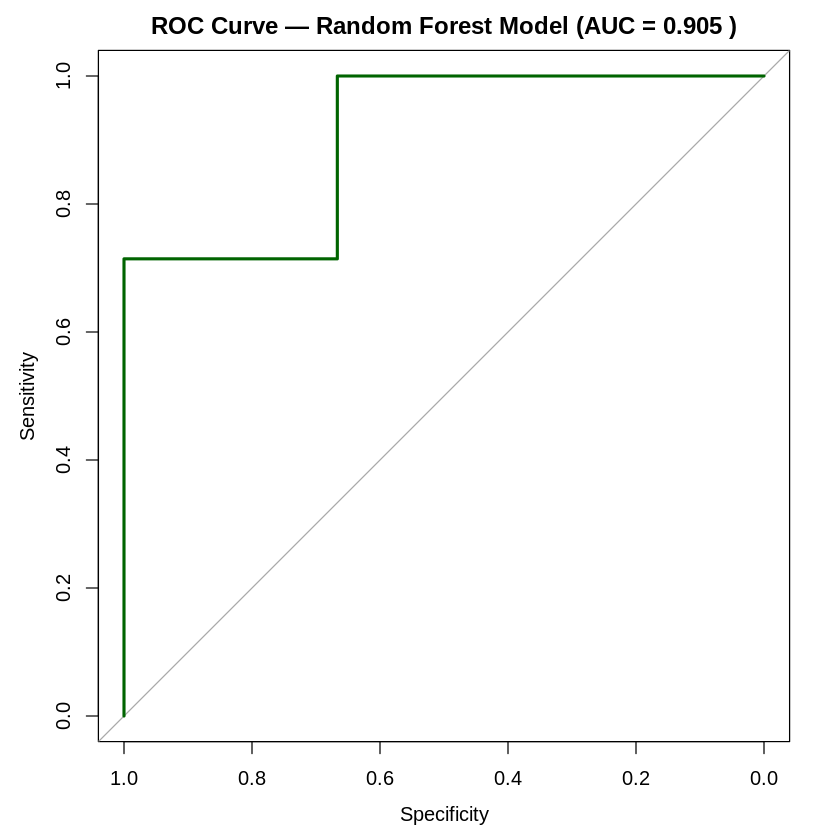

In [109]:
# ── 5.7 ROC Curve for Random Forest ──────────────────────────────────────

# Re-creating the Random Forest model to ensure 'rf_model' is available.
# This might be necessary if the kernel state was reset or cell 5.6 was not run.
set.seed(42)
rf_model <- randomForest(x = X,
                          y = as.factor(condition),
                          ntree = 500,
                          importance = TRUE)

# Get probabilities for the positive class (PCOS)
rf_probs <- predict(rf_model, type = "prob")[, "PCOS"]

# Create ROC curve
roc_curve_rf <- roc(y, as.vector(rf_probs))

# Plot ROC curve
plot(roc_curve_rf,
     main = paste("ROC Curve — Random Forest Model (AUC =", round(auc(roc_curve_rf), 3), ")"),
     col = "darkgreen", lwd = 2.5)

cat("\nRandom Forest Model AUC:", round(auc(roc_curve_rf), 3), "\n")

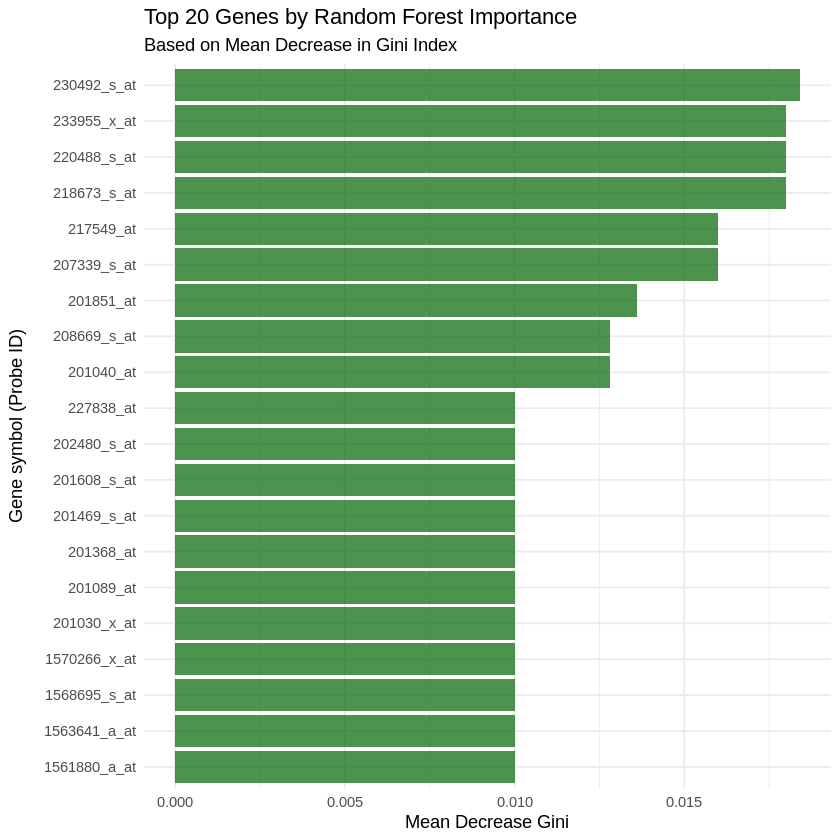

In [110]:
# ── 5.8 Random Forest Feature Importance Visualization ──────────────────
# Extract importance and create a data frame
rf_importance <- as.data.frame(importance(rf_model))
rf_importance$Gene <- rownames(rf_importance)

# Sort by MeanDecreaseGini and take top 20
top_20_rf <- rf_importance[order(rf_importance$MeanDecreaseGini, decreasing = TRUE), ][1:20, ]

# Plot using ggplot2
ggplot(top_20_rf, aes(x = reorder(Gene, MeanDecreaseGini), y = MeanDecreaseGini)) +
  geom_bar(stat = "identity", fill = "darkgreen", alpha = 0.7) +
  coord_flip() +
  labs(
    title = "Top 20 Genes by Random Forest Importance",
    subtitle = "Based on Mean Decrease in Gini Index",
    x = "Gene symbol (Probe ID)",
    y = "Mean Decrease Gini"
  ) +
  theme_minimal()

---
## Section 6: Summary and Export Results


In [111]:
# Print analysis summary
cat("                    ANALYSIS SUMMARY                       \n")
cat("Dataset: GSE34526\n")
cat("Total samples:", ncol(exprs_filtered), "\n")
cat("PCOS:", sum(condition == "PCOS"), "\n")
cat("Control:", sum(condition == "Control"), "\n")
cat("Genes after filtering:", nrow(exprs_filtered), "\n")
cat("Significant DEGs:", nrow(sig_degs), "\n")
cat("Upregulated:", sum(sig_degs$logFC > 0), "\n")
cat("Downregulated:", sum(sig_degs$logFC < 0), "\n")
cat("Random Forest AUC:", round(auc(roc_curve_rf), 3), "\n")
# Lasso results unavailable due to small sample size
# cat("Lasso-selected genes:", length(selected_genes), "\n")
# cat("Lasso AUC:", round(auc(roc_curve), 3), "\n")
cat("============================================================\n")

                    ANALYSIS SUMMARY                       
Dataset: GSE34526
Total samples: 10 
PCOS: 7 
Control: 3 
Genes after filtering: 24110 
Significant DEGs: 11 
Upregulated: 1 
Downregulated: 10 
Random Forest AUC: 0.905 


In [112]:
# Export results to CSV
write.csv(deg_results, "PCOS_DEG_All_Results.csv", row.names = TRUE)
write.csv(sig_degs, "PCOS_Significant_DEGs.csv", row.names = TRUE)

# Only export Lasso genes if they exist (skipping here as Lasso failed)
# write.csv(data.frame(Gene = selected_genes), "PCOS_Lasso_Selected_Genes.csv", row.names = FALSE)

cat("Results Exported:\n")
cat("   - PCOS_DEG_All_Results.csv\n")
cat("   - PCOS_Significant_DEGs.csv\n")

Results Exported:
   - PCOS_DEG_All_Results.csv
   - PCOS_Significant_DEGs.csv
